# Sandpiles Project
### COMP90072 Art of Scientific Computation
### Jonathan Purcell

In [1]:
%matplotlib widget

In [2]:
from sandpiles import *
import matplotlib.pyplot as plt
from typing import Any

## Simulation

In [3]:
n_steps = 5_000_000         # number of steps in the simulation (after burn in)
burn_in = 200_000           # number of steps to establish the system, so that data is not corrupted
gridsizes = [5, 10, 20, 50] # finite lattice sizing

np.random.seed(1)           # ensure reproducibility

sims: dict[int, SandpileSimulation] = {}

# run simulations for increasing finite grid size
for grid in gridsizes:
    sims[grid] = SandpileSimulation((grid, grid), n_steps, burn_in)

## Sandpile Topples

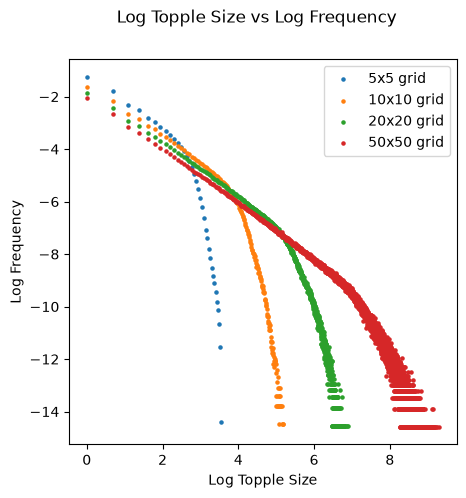

In [4]:
# show standard and log-log plot side-by-side
fig, ax = plt.subplots(1, 1, figsize = (5, 5))

ax.set_xlabel("Log Topple Size")
ax.set_ylabel("Log Frequency")
for grid in gridsizes:
    visualise_statistic(sims[grid].topples, include_zero=False, log=True, ax=ax, s=5, label=f"{grid}x{grid} grid")

fig.suptitle("Log Topple Size vs Log Frequency")
plt.legend()
plt.show()

The plots above indicate a potential power-law relationship between topple size and frequency, up to a finite cutoff due to the experiment boundary. To address the boundary effect, we model the distribution of topple size as an exponentially-truncated power law distribution. Let $X$ be the random variable representing the size of a given topple.
$$p(X=x; \alpha, \lambda) = \frac{1}{\text{Li}_\alpha(e^{-\lambda})}x^{-\alpha}e^{-\lambda x}$$
where $\text{Li}_\alpha(x) = \sum_{k=1}^\infty x^k / k^\alpha$ is the polylogarithm function.

For smaller topple sizes, the power law term will dominate, while the exponential decay term will dominate for larger size topples. From this, we can extract the approximate power law coefficient $\alpha$.

We fit values of $\alpha$ and $\lambda$ using the simulated dataset using Maximum Likelihood Estimation (MLE). Denote $\mathbf{X} = (X_1, X_2, \cdots, X_n)$ where $n$ is the number of (non-zero) topples observed during the simulation.

\begin{align*}
    \mathcal{L}(\mathbf{X}; \alpha, \lambda) &= \prod_{i=1}^{n} \frac{1}{\text{Li}_\alpha(e^{-\lambda})}x_i^{-\alpha}e^{-\lambda x_i} \\
    \ln \mathcal{L}(\mathbf{X}; \alpha, \lambda) &= \sum_{i=1}^{n} -\ln{\text{Li}_\alpha(e^{-\lambda})} - \alpha \ln(x_i) - \lambda x_i \\
    &= -n \ln {\text{Li}_{\alpha}(e^{-\lambda})} - \alpha \sum_{i=1}^n \ln(x_i) - \lambda \sum_{i=1}^n x_i\\
    \hat{\alpha}, \hat{\lambda} &= \argmax_{\alpha, \lambda} \left(-n \ln {\text{Li}_{\alpha}(e^{-\lambda})} - \alpha \sum_{i=1}^n \ln(x_i) - \lambda \sum_{i=1}^n x_i\right) \\
    &= \argmin_{\alpha, \lambda} \left(n \ln {\text{Li}_{\alpha}(e^{-\lambda})} + \alpha \sum_{i=1}^n \ln(x_i) + \lambda \sum_{i=1}^n x_i\right)\\
\end{align*}

We can solve this using existing optimisation implementations in Python.

In [5]:
params: dict[int, Any] = {}
for grid in gridsizes:
    params[grid] = compute_MLE(sims[grid].topples[sims[grid].topples > 0], pmf=etdpl_pmf, p0 = (0.5, 0.01), bounds=((1e-8, None), (1e-8, None))).x
    print(f"{grid}x{grid} lattice: alpha = {params[grid][0]}, lambda = {params[grid][1]}")

5x5 lattice: alpha = 0.4506725074525399, lambda = 0.16120250648317122
10x10 lattice: alpha = 0.7403198063726671, lambda = 0.03299554645634949
20x20 lattice: alpha = 0.8806363086361322, lambda = 0.006331712849893677
50x50 lattice: alpha = 0.9824058232460932, lambda = 0.0006608405724383605


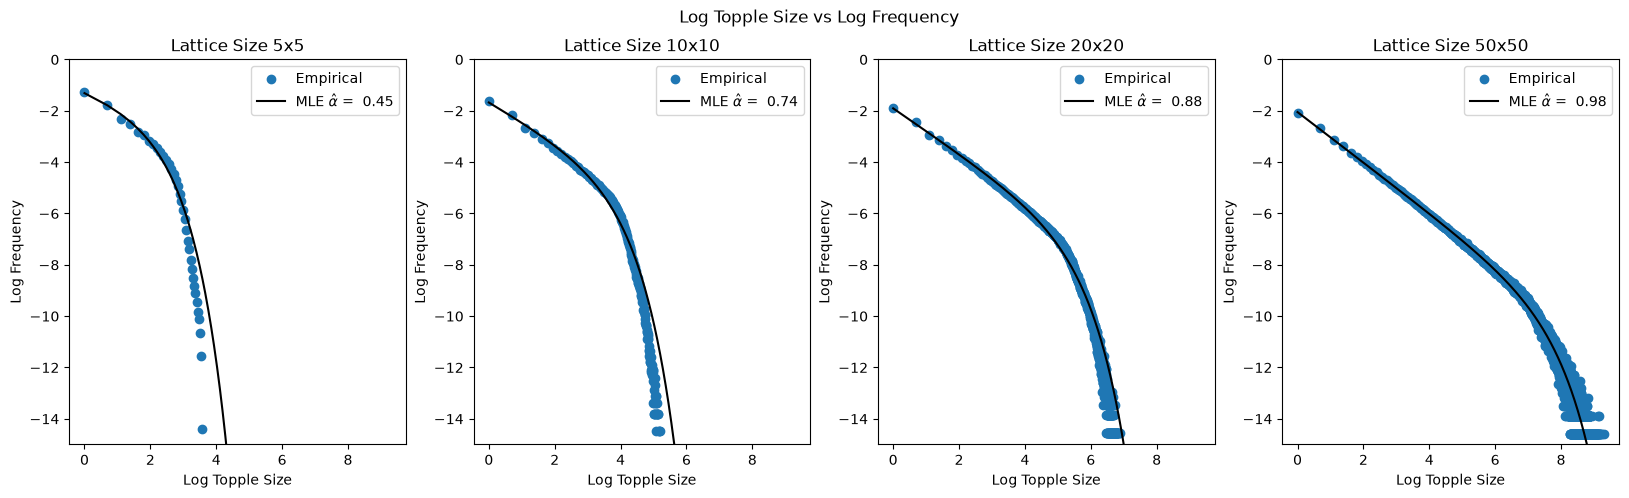

In [6]:
# show log-log plot of different lattice size on same axes
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i, grid in enumerate(gridsizes):
    x = np.arange(1, max(sims[max(gridsizes)].topples) + 1)
    log_pmf_mle = etdpl_pmf(params = (params[grid][0], params[grid][1]), x=x, loglik = True)
    ax[i].set_xlabel("Log Topple Size")
    ax[i].set_ylabel("Log Frequency")
    visualise_statistic(sims[grid].topples, include_zero=False, log=True, ax=ax[i], label=f"Empirical")
    ax[i].plot(np.log(x), log_pmf_mle, label="MLE " + r"$\hat{\alpha}$" + f" = {params[grid][0]: .2f}", color="black")
    ax[i].set_ylim((-15, 0))
    ax[i].set_title(f"Lattice Size {grid}x{grid}")
    ax[i].legend()
fig.suptitle("Log Topple Size vs Log Frequency")
plt.show()

The exponential decay penalty does not appear strong enough for smaller grid sizes, which changes the estimated power law. To improve the consistency of the estimate, we introduce a superexponential decay parameter $\beta \geq 1$:
$$p(X=x; \alpha, \lambda, \beta) = \frac{1}{C(\alpha, \lambda, \beta)}x^{-\alpha}e^{-\lambda x^\beta}$$
where $$C(\alpha, \lambda, \beta) = \sum_{k=1}^\infty k^{-\alpha}e^{-\lambda k^\beta}$$

In [8]:
super_params: dict[int, Any] = {}
for grid in gridsizes:
    super_params[grid] = compute_MLE(sims[grid].topples[sims[grid].topples > 0], pmf=setdpl_pmf, p0 = (0.98, 1e-5, 1.01), bounds=((1e-8, None), (1e-8, None), (1, None))).x
    print(f"{grid}x{grid} lattice: alpha = {super_params[grid][0]}, lambda = {super_params[grid][1]}, beta={super_params[grid][2]}")

5x5 lattice: alpha = 0.9352052320881231, lambda = 0.00026056281018465644, beta=2.943596053155162
10x10 lattice: alpha = 0.9349036931302216, lambda = 0.0001498478678565018, beta=2.165905290415684
20x20 lattice: alpha = 0.9442762439770485, lambda = 0.0003427839336580117, beta=1.4762139951444806
50x50 lattice: alpha = 0.9799992875271795, lambda = 0.0006166514346684052, beta=1.009996785570475


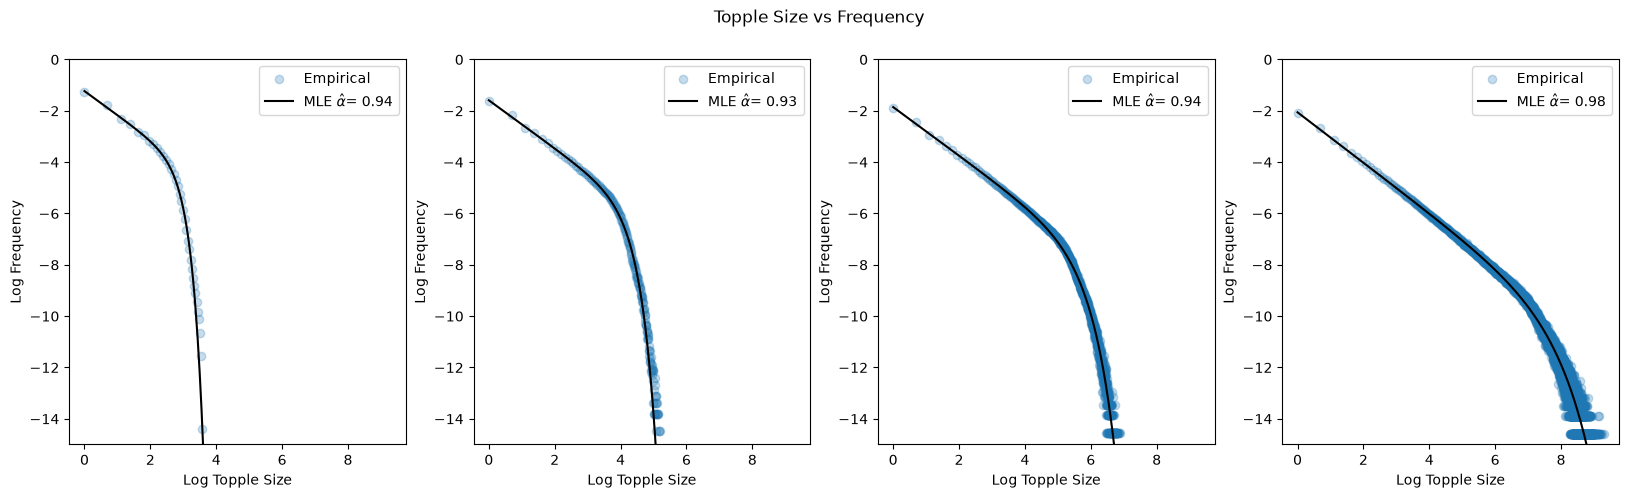

In [13]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i, grid in enumerate(gridsizes):
    x = np.arange(1, max(sims[max(gridsizes)].topples) + 1)
    log_pmf_mle = setdpl_pmf(params = (super_params[grid][0], super_params[grid][1], super_params[grid][2]), x=x, loglik = True)
    ax[i].set_xlabel("Log Topple Size")
    ax[i].set_ylabel("Log Frequency")
    visualise_statistic(sims[grid].topples, include_zero=False, log=True, ax=ax[i], label=f"Empirical", alpha=0.25)
    ax[i].plot(np.log(x), log_pmf_mle, label="MLE " r"$\hat{\alpha}$=" + f"{super_params[grid][0]: .2f}", color="black")

    ax[i].set_ylim((-15, 0))
    ax[i].legend()
fig.suptitle("Topple Size vs Frequency")
plt.show()

The result above indicates that toppling size is governed by an approximate power law distribution, where $$p(s) \propto s^{-0.94}$$ This relationship is obtained across varying lattice sizes, giving evidence of self-organised criticality.